In [0]:
dbutils.widgets.dropdown("shap_enabled", "true", ["true", "false"], "Compute shape feature importance")

# Use the best Auto-ML generated notebook to bootstrap our ML Project

<img src="https://raw.githubusercontent.com/QuentinAmbard/databricks-demo/main/retail/resources/images/lakehouse-retail/lakehouse-retail-churn-ml-experiment.png" style="float: right" width="600px">

Databricks Autt-ML tries many models and generate notebooks containing the code used to build the model.

Here, we selected the notebook from best run from the Auto ML experiment.

All the code below has been automatically generated. As Data Scientist, we can tune it based on our business knowledge, or use the model generated as it is.

This saves Datascientists hours of developement and allow team to quickly bootstrap and validate new project.

**All the cells below have been automatically generated.**

<!-- Collect usage data (view). Remove it to disable collection. View README for more details.  -->
<img width="1px" src="https://ppxrzfxige.execute-api.us-west-2.amazonaws.com/v1/analytics?category=lakehouse&org_id=2162748966026566&notebook=%2F04-Data-Science-ML%2F04.2-automl-generated-notebook-fraud&demo_name=lakehouse-fsi-fraud&event=VIEW&path=%2F_dbdemos%2Flakehouse%2Flakehouse-fsi-fraud%2F04-Data-Science-ML%2F04.2-automl-generated-notebook-fraud&version=1">

In [0]:
%pip install databricks-sdk==0.36.0 mlflow==2.19.0
# Hardcode dbrml 15.4 version here to avoid version conflict
%pip install cloudpickle==2.2.1 databricks-automl-runtime==0.2.21 category-encoders==2.6.3 holidays==0.54 lightgbm==4.5.0 shap==0.46.0 https://github.com/databricks-demos/dbdemos-resources/raw/refs/heads/main/hyperopt-0.2.8-py3-none-any.whl networkx==3.2.1 scikit-learn==1.4.2
dbutils.library.restartPython()

  Using cached databricks_sdk-0.36.0-py3-none-any.whl.metadata (38 kB)
  Using cached mlflow-2.19.0-py3-none-any.whl.metadata (30 kB)
  Using cached mlflow_skinny-2.19.0-py3-none-any.whl.metadata (31 kB)
  Using cached docker-7.1.0-py3-none-any.whl.metadata (3.8 kB)
  Using cached graphene-3.4.3-py2.py3-none-any.whl.metadata (6.9 kB)
  Using cached graphql_relay-3.2.0-py3-none-any.whl.metadata (12 kB)
Using cached databricks_sdk-0.36.0-py3-none-any.whl (569 kB)
Using cached mlflow-2.19.0-py3-none-any.whl (27.4 MB)
Using cached mlflow_skinny-2.19.0-py3-none-any.whl (5.9 MB)
Using cached docker-7.1.0-py3-none-any.whl (147 kB)
Using cached graphene-3.4.3-py2.py3-none-any.whl (114 kB)
Using cached graphql_relay-3.2.0-py3-none-any.whl (16 kB)
  Attempting uninstall: databricks-sdk
    Found existing installation: databricks-sdk 0.30.0
    Not uninstalling databricks-sdk at /databricks/python3/lib/python3.12/site-packages, outside environment /local_disk0/.ephemeral_nfs/envs/pythonEnv-046500

In [0]:
%run ../_resources/00-setup $reset_all_data=false

USE CATALOG `main__build`
using catalog.database `main__build`.`dbdemos_fsi_fraud_detection`


# RandomForest Classifier training

- This is an auto-generated notebook.
- To reproduce these results, attach this notebook to a cluster with runtime version **12.1.x-cpu-ml-scala2.12**, and rerun it.
- Compare trials in the [MLflow experiment](#mlflow/experiments/3254325001193021).
- Clone this notebook into your project folder by selecting **File > Clone** in the notebook toolbar.

In [0]:
import mlflow
import databricks.automl_runtime
#Added for the demo purpose
xp = DBDemos.get_last_experiment("lakehouse-fsi-fraud-detection")

# Use MLflow to track experiments
mlflow.set_experiment(xp["path"])

#Run containing the data analysis notebook to get the data from artifact
data_run = mlflow.search_runs(filter_string="tags.mlflow.source.name='Notebook: DataExploration'").iloc[0].to_dict()

#get best run id (this notebook)
df = mlflow.search_runs(filter_string="metrics.val_f1_score < 1")
run = df.sort_values(by="metrics.val_f1_score", ascending=False).iloc[0].to_dict()

target_col = "is_fraud"

## Load Data

In [0]:
import mlflow
import os
import uuid
import shutil
import pandas as pd

# Create temp directory to download input data from MLflow
input_temp_dir = os.path.join(os.environ["SPARK_LOCAL_DIRS"], "tmp", str(uuid.uuid4())[:8])
os.makedirs(input_temp_dir)


# Download the artifact and read it into a pandas DataFrame
input_data_path = mlflow.artifacts.download_artifacts(run_id=data_run["run_id"], artifact_path="data", dst_path=input_temp_dir)

df_loaded = pd.read_parquet(os.path.join(input_data_path, "training_data"))
# Delete the temp data
shutil.rmtree(input_temp_dir)
try:
    df_loaded = df_loaded.drop(['_automl_sample_weight_0000'], axis=1) #for demo only, to make it more stable across versions.
except:
    print('column weight not available - this might change depending on the automl version - can ignore')
    
# Preview data
df_loaded.head(5)

,id,amount,isUnauthorizedOverdraft,nameDest,nameOrig,newBalanceDest,newBalanceOrig,oldBalanceDest,oldBalanceOrig,step,type,diffOrig,diffDest,country,last_country_logged,age_group,countryOrig,countryOrig_name,countryLongOrig_long,countryLatOrig_lat,countryDest,countryDest_name,countryLongDest_long,countryLatDest_lat,is_fraud,_automl_split_col_0000
0,003599cb-0237-4311-a90a-07698bed98e1,1923.94,0,B3405041374,C3209033346,0.00,2131335.96,0.00,2133259.90,503,DEBIT,-1923.94,0.00,BRB,BRB,9.0,CAN,Canada,-95,60,PER,Peru,-76,-10,False,train
1,007da48b-8f50-4d6d-969b-04a93dd5210e,2047.83,0,M6943064832,C0644814716,1471116.08,1361084.47,1469068.25,1363132.30,474,PAYMENT,-2047.83,2047.83,NGA,NGA,4.0,RUS,Russian Federation,100,60,FRA,France,2,46,False,train
2,007f4f12-d1d1-41b9-8c86-fe8a67cd26a7,5790.00,0,M4779660592,C4917168919,1259429.33,3193760.29,1253639.33,3199550.29,383,PAYMENT,-5790.00,5790.00,ALB,ALB,3.0,RUS,Russian Federation,100,60,RUS,Russian Federation,100,60,False,train
3,008f7007-85ba-4703-a146-2216a64949fc,400000.00,0,CC0186484978,C5164612040,2587284.24,2518345.23,2187284.24,2918345.23,284,TRANSFER,-400000.00,400000.00,NGA,NGA,6.0,QAT,Qatar,51.25,25.5,CAN,Canada,-95,60,False,train
4,00f0c5f7-3f01-489d-91d1-16710876f231,187018.51,0,M6095322189,C9076320006,109996.65,3667851.71,109996.65,3480833.20,27,CASH_IN,187018.51,0.00,DMA,DMA,9.0,TUR,Turkey,35,39,BRA,Brazil,-55,-10,False,train


### Select supported columns
Select only the columns that are supported. This allows us to train a model that can predict on a dataset that has extra columns that are not used in training.
`["_rescued_data", "nameOrig", "id", "nameDest", "customer_id"]` are dropped in the pipelines. See the Alerts tab of the AutoML Experiment page for details on why these columns are dropped.

In [0]:
from databricks.automl_runtime.sklearn.column_selector import ColumnSelector
supported_cols = ["country", "countryLatDest_lat", "oldBalanceDest", "last_country_logged", "step", "countryOrig", "countryOrig_name", "newBalanceDest", "countryDest_name", "countryLongOrig_long", "isUnauthorizedOverdraft", "newBalanceOrig", "nameDest", "countryLongDest_long", "type", "countryDest", "age_group", "countryLatOrig_lat", "nameOrig", "diffOrig", "amount", "diffDest", "oldBalanceOrig"]
col_selector = ColumnSelector(supported_cols)

## Preprocessors

### Boolean columns
For each column, impute missing values and then convert into ones and zeros.

In [0]:
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import FunctionTransformer
from sklearn.preprocessing import OneHotEncoder as SklearnOneHotEncoder


bool_imputers = []

bool_pipeline = Pipeline(steps=[
    ("cast_type", FunctionTransformer(lambda df: df.astype(object))),
    ("imputers", ColumnTransformer(bool_imputers, remainder="passthrough")),
    ("onehot", SklearnOneHotEncoder(handle_unknown="ignore", drop="first")),
])

bool_transformers = [("boolean", bool_pipeline, ["isUnauthorizedOverdraft"])]

### Numerical columns

Missing values for numerical columns are imputed with mean by default.

In [0]:
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import FunctionTransformer, StandardScaler

num_imputers = []
num_imputers.append(("impute_mean", SimpleImputer(), ["age_group", "amount", "diffDest", "diffOrig", "isUnauthorizedOverdraft", "newBalanceDest", "newBalanceOrig", "oldBalanceDest", "oldBalanceOrig", "step"]))

numerical_pipeline = Pipeline(steps=[
    ("converter", FunctionTransformer(lambda df: df.apply(pd.to_numeric, errors='coerce'))),
    ("imputers", ColumnTransformer(num_imputers)),
    ("standardizer", StandardScaler()),
])

numerical_transformers = [("numerical", numerical_pipeline, ["isUnauthorizedOverdraft", "newBalanceOrig", "oldBalanceDest", "diffOrig", "amount", "diffDest", "step", "newBalanceDest", "age_group", "oldBalanceOrig"])]

### Categorical columns

#### Low-cardinality categoricals
Convert each low-cardinality categorical column into multiple binary columns through one-hot encoding.
For each input categorical column (string or numeric), the number of output columns is equal to the number of unique values in the input column.

In [0]:
from databricks.automl_runtime.sklearn import OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline

one_hot_imputers = []

one_hot_pipeline = Pipeline(steps=[
    ("imputers", ColumnTransformer(one_hot_imputers, remainder="passthrough")),
    ("one_hot_encoder", OneHotEncoder(handle_unknown="indicator")),
])

categorical_one_hot_transformers = [("onehot", one_hot_pipeline, ["country", "countryDest", "countryDest_name", "countryLatDest_lat", "countryLatOrig_lat", "countryLongDest_long", "countryLongOrig_long", "countryOrig", "countryOrig_name", "last_country_logged", "type"])]

#### Medium-cardinality categoricals
Convert each medium-cardinality categorical column into a numerical representation.
Each string column is hashed to 1024 float columns.

In [0]:
from sklearn.feature_extraction import FeatureHasher
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline
from sklearn.compose import make_column_selector
from sklearn.preprocessing import FunctionTransformer

imputers = {
}

string_cols = ["nameDest", "nameOrig"]
categorical_numerical_cols = []
categorical_hash_transformers = []

for col in (string_cols + categorical_numerical_cols):
    steps = []
    if col in categorical_numerical_cols:
        steps.append(
            (f"{col}_to_str", FunctionTransformer(lambda x: pd.DataFrame(x).astype(str)))
        )
    if col in imputers:
        imputer_name, imputer = imputers[col]
    else:
        imputer_name, imputer = "impute_string_", SimpleImputer(fill_value='', missing_values=None, strategy='constant')
    steps += [
        (imputer_name, imputer),
        (f"{col}_hasher", FeatureHasher(n_features=1024, input_type="string"))
    ]
    hash_pipeline = Pipeline(steps=steps)
    categorical_hash_transformers.append((f"{col}_pipeline", hash_pipeline, [col]))

In [0]:
from sklearn.compose import ColumnTransformer

transformers = bool_transformers + numerical_transformers + categorical_one_hot_transformers + categorical_hash_transformers

preprocessor = ColumnTransformer(transformers, remainder="passthrough", sparse_threshold=1)

## Train - Validation - Test Split
The input data is split by AutoML into 3 sets:
- Train (60% of the dataset used to train the model)
- Validation (20% of the dataset used to tune the hyperparameters of the model)
- Test (20% of the dataset used to report the true performance of the model on an unseen dataset)

`_automl_split_col_0000` contains the information of which set a given row belongs to.
We use this column to split the dataset into the above 3 sets. 
The column should not be used for training so it is dropped after split is done.

In [0]:
# AutoML completed train - validation - test split internally and used _automl_split_col_0000 to specify the set
split_col = [c for c in df_loaded.columns if c.startswith('_automl_split_col')][0]
split_train_df = df_loaded.loc[df_loaded[split_col] == "train"]
split_val_df = df_loaded.loc[df_loaded[split_col].isin(["val", "validate"])]
split_test_df = df_loaded.loc[df_loaded[split_col] == "test"]

# Separate target column from features and drop _automl_split_col_0000
X_train = split_train_df.drop([target_col, split_col], axis=1)
y_train = split_train_df[target_col]

X_val = split_val_df.drop([target_col, split_col], axis=1)
y_val = split_val_df[target_col]

X_test = split_test_df.drop([target_col, split_col], axis=1)
y_test = split_test_df[target_col]

## Train classification model
- Log relevant metrics to MLflow to track runs
- All the runs are logged under [this MLflow experiment](#mlflow/experiments/3254325001193021)
- Change the model parameters and re-run the training cell to log a different trial to the MLflow experiment
- To view the full list of tunable hyperparameters, check the output of the cell below

In [0]:
import lightgbm
from lightgbm import LGBMClassifier

help(LGBMClassifier)

Help on class LGBMClassifier in module lightgbm.sklearn:

class LGBMClassifier(sklearn.base.ClassifierMixin, LGBMModel)
 |  LGBMClassifier(boosting_type: str = 'gbdt', num_leaves: int = 31, max_depth: int = -1, learning_rate: float = 0.1, n_estimators: int = 100, subsample_for_bin: int = 200000, objective: Union[str, Callable[[Optional[numpy.ndarray], numpy.ndarray], Tuple[numpy.ndarray, numpy.ndarray]], Callable[[Optional[numpy.ndarray], numpy.ndarray, Optional[numpy.ndarray]], Tuple[numpy.ndarray, numpy.ndarray]], Callable[[Optional[numpy.ndarray], numpy.ndarray, Optional[numpy.ndarray], Optional[numpy.ndarray]], Tuple[numpy.ndarray, numpy.ndarray]], NoneType] = None, class_weight: Union[Dict, str, NoneType] = None, min_split_gain: float = 0.0, min_child_weight: float = 0.001, min_child_samples: int = 20, subsample: float = 1.0, subsample_freq: int = 0, colsample_bytree: float = 1.0, reg_alpha: float = 0.0, reg_lambda: float = 0.0, random_state: Union[int, numpy.random.mtrand.RandomS

### Define the objective function
The objective function used to find optimal hyperparameters. By default, this notebook only runs
this function once (`max_evals=1` in the `hyperopt.fmin` invocation) with fixed hyperparameters, but
hyperparameters can be tuned by modifying `space`, defined below. `hyperopt.fmin` will then use this
function's return value to search the space to minimize the loss.

In [0]:
X_train

,id,amount,isUnauthorizedOverdraft,nameDest,nameOrig,newBalanceDest,newBalanceOrig,oldBalanceDest,oldBalanceOrig,step,type,diffOrig,diffDest,country,last_country_logged,age_group,countryOrig,countryOrig_name,countryLongOrig_long,countryLatOrig_lat,countryDest,countryDest_name,countryLongDest_long,countryLatDest_lat
0,003599cb-0237-4311-a90a-07698bed98e1,1923.94,0,B3405041374,C3209033346,0.00,2131335.96,0.00,2133259.90,503,DEBIT,-1923.94,0.00,BRB,BRB,9.0,CAN,Canada,-95,60,PER,Peru,-76,-10
1,007da48b-8f50-4d6d-969b-04a93dd5210e,2047.83,0,M6943064832,C0644814716,1471116.08,1361084.47,1469068.25,1363132.30,474,PAYMENT,-2047.83,2047.83,NGA,NGA,4.0,RUS,Russian Federation,100,60,FRA,France,2,46
2,007f4f12-d1d1-41b9-8c86-fe8a67cd26a7,5790.00,0,M4779660592,C4917168919,1259429.33,3193760.29,1253639.33,3199550.29,383,PAYMENT,-5790.00,5790.00,ALB,ALB,3.0,RUS,Russian Federation,100,60,RUS,Russian Federation,100,60
3,008f7007-85ba-4703-a146-2216a64949fc,400000.00,0,CC0186484978,C5164612040,2587284.24,2518345.23,2187284.24,2918345.23,284,TRANSFER,-400000.00,400000.00,NGA,NGA,6.0,QAT,Qatar,51.25,25.5,CAN,Canada,-95,60
4,00f0c5f7-3f01-489d-91d1-16710876f231,187018.51,0,M6095322189,C9076320006,109996.65,3667851.71,109996.65,3480833.20,27,CASH_IN,187018.51,0.00,DMA,DMA,9.0,TUR,Turkey,35,39,BRA,Brazil,-55,-10
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
47645,fdc1cb0c-a773-48c4-9d37-3e5eb4964b91,90170.93,0,M5552562659,C9487106967,1503778.85,3639639.89,1503778.85,3729810.82,526,CASH_OUT,-90170.93,0.00,KHM,KHM,3.0,ITA,Italy,12.8333,42.8333,ESP,Spain,-4,40
47646,fe56f823-bc91-4317-b06c-bca67f064855,34268.25,0,M2250022491,C7765567945,680612.59,1823983.39,680612.59,1858251.64,284,CASH_OUT,-34268.25,0.00,MCO,MCO,10.0,PSE,"Palestinian Territory, Occupied",35.25,32,FRA,France,2,46
47647,fe715eef-04a8-450a-b36c-04101dde4cb3,86366.38,0,M7278948151,C0683612122,657111.98,2262873.01,657111.98,2176506.62,236,CASH_IN,86366.39,0.00,MNE,MNE,6.0,REU,Réunion,55.6,-21.1,REU,Réunion,55.6,-21.1
47648,fed6650a-5faa-48fc-b0dd-5bcdec46af4f,15898.55,0,M5158762961,C2261895169,273417.44,3554216.33,273417.44,3538317.78,48,CASH_IN,15898.55,0.00,KAZ,KAZ,1.0,FRA,France,2,46,NGA,Nigeria,8,10


In [0]:
import mlflow
from mlflow.models import Model, infer_signature, ModelSignature
from mlflow.pyfunc import PyFuncModel
from mlflow import pyfunc
import sklearn
from sklearn import set_config
from sklearn.pipeline import Pipeline

from hyperopt import hp, tpe, fmin, STATUS_OK, Trials

# Create a separate pipeline to transform the validation dataset. This is used for early stopping.
mlflow.sklearn.autolog(disable=True)
pipeline_val = Pipeline([
    ("column_selector", col_selector),
    ("preprocessor", preprocessor),
])
pipeline_val.fit(X_train, y_train)
X_val_processed = pipeline_val.transform(X_val)
dataset = mlflow.data.from_pandas(X_train)

def objective(params):
  with mlflow.start_run(experiment_id=run['experiment_id']) as mlflow_run:
    lgbmc_classifier = LGBMClassifier(**params)
    mlflow.log_input(dataset, "training")
    model = Pipeline([
        ("column_selector", col_selector),
        ("preprocessor", preprocessor),
        ("classifier", lgbmc_classifier),
    ])

    # Enable automatic logging of input samples, metrics, parameters, and models
    mlflow.sklearn.autolog(
        log_input_examples=True,
        silent=True)

    model.fit(X_train, y_train, classifier__callbacks=[lightgbm.early_stopping(5), lightgbm.log_evaluation(0)], classifier__eval_set=[(X_val_processed,y_val)])

    
    # Log metrics for the training set
    mlflow_model = Model()
    pyfunc.add_to_model(mlflow_model, loader_module="mlflow.sklearn")
    pyfunc_model = PyFuncModel(model_meta=mlflow_model, model_impl=model)
    training_eval_result = mlflow.evaluate(
        model=pyfunc_model,
        data=X_train.assign(**{str(target_col):y_train}),
        targets=target_col,
        model_type="classifier",
        evaluator_config = {"log_model_explainability": False,
                            "metric_prefix": "training_" , "pos_label": 1 }
    )
    lgbmc_training_metrics = training_eval_result.metrics
    # Log metrics for the validation set
    val_eval_result = mlflow.evaluate(
        model=pyfunc_model,
        data=X_val.assign(**{str(target_col):y_val}),
        targets=target_col,
        model_type="classifier",
        evaluator_config = {"log_model_explainability": False,
                            "metric_prefix": "val_" , "pos_label": 1 }
    )
    lgbmc_val_metrics = val_eval_result.metrics
    # Log metrics for the test set
    test_eval_result = mlflow.evaluate(
        model=pyfunc_model,
        data=X_test.assign(**{str(target_col):y_test}),
        targets=target_col,
        model_type="classifier",
        evaluator_config = {"log_model_explainability": False,
                            "metric_prefix": "test_" , "pos_label": 1 }
    )
    lgbmc_test_metrics = test_eval_result.metrics

    loss = -lgbmc_val_metrics["val_f1_score"]

    # Truncate metric key names so they can be displayed together
    lgbmc_val_metrics = {k.replace("val_", ""): v for k, v in lgbmc_val_metrics.items()}
    lgbmc_test_metrics = {k.replace("test_", ""): v for k, v in lgbmc_test_metrics.items()}

    return {
      "loss": loss,
      "status": STATUS_OK,
      "val_metrics": lgbmc_val_metrics,
      "test_metrics": lgbmc_test_metrics,
      "model": model,
      "run": mlflow_run,
    }

(2025-11-03 22:50:05) WARNING: Hyperopt is deprecated for Databricks runtime for machine learning and will not be pre-installed in the next major version.


### Configure the hyperparameter search space
Configure the search space of parameters. Parameters below are all constant expressions but can be
modified to widen the search space. For example, when training a decision tree classifier, to allow
the maximum tree depth to be either 2 or 3, set the key of 'max_depth' to
`hp.choice('max_depth', [2, 3])`. Be sure to also increase `max_evals` in the `fmin` call below.

See https://docs.databricks.com/applications/machine-learning/automl-hyperparam-tuning/index.html
for more information on hyperparameter tuning as well as
http://hyperopt.github.io/hyperopt/getting-started/search_spaces/ for documentation on supported
search expressions.

For documentation on parameters used by the model in use, please see:
https://scikit-learn.org/stable/modules/generated/sklearn.ensemble.RandomForestClassifier.html

NOTE: The above URL points to a stable version of the documentation corresponding to the last
released version of the package. The documentation may differ slightly for the package version
used by this notebook.

In [0]:
space = {
  "colsample_bytree": 0.5999483787089168,
  "lambda_l1": 81.57656654199066,
  "lambda_l2": 1.0663947995038876,
  "learning_rate": 0.04879996983965328,
  "max_bin": 193,
  "max_depth": 9,
  "min_child_samples": 175,
  "n_estimators": 2478,
  "num_leaves": 6,
  "path_smooth": 88.39418345705647,
  "subsample": 0.7254157304746242,
  "random_state": 704178917,
}

### Run trials
When widening the search space and training multiple models, switch to `SparkTrials` to parallelize
training on Spark:
```
from hyperopt import SparkTrials
trials = SparkTrials()
```

NOTE: While `Trials` starts an MLFlow run for each set of hyperparameters, `SparkTrials` only starts
one top-level run; it will start a subrun for each set of hyperparameters.

See http://hyperopt.github.io/hyperopt/scaleout/spark/ for more info.

In [0]:
trials = Trials()
fmin(objective,
     space=space,
     algo=tpe.suggest,
     max_evals=1,  # Increase this when widening the hyperparameter search space.
     trials=trials)

best_result = trials.best_trial["result"]
model = best_result["model"]
mlflow_run = best_result["run"]

display(
  pd.DataFrame(
    [best_result["val_metrics"], best_result["test_metrics"]],
    index=["validation", "test"]))

set_config(display="diagram")
model

[LightGBM] [Warning] lambda_l2 is set=1.0663947995038876, reg_lambda=0.0 will be ignored. Current value: lambda_l2=1.0663947995038876
[LightGBM] [Warning] lambda_l1 is set=81.57656654199066, reg_alpha=0.0 will be ignored. Current value: lambda_l1=81.57656654199066
[LightGBM] [Warning] lambda_l2 is set=1.0663947995038876, reg_lambda=0.0 will be ignored. Current value: lambda_l2=1.0663947995038876
[LightGBM] [Warning] lambda_l1 is set=81.57656654199066, reg_alpha=0.0 will be ignored. Current value: lambda_l1=81.57656654199066
[LightGBM] [Info] Number of positive: 2165, number of negative: 45485
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000615 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 2290
[LightGBM] [Info] Number of data points in the train set: 47650, number of used features: 375
[LightGBM] [Warning] lambda_l2 is set=1.066394

Uploading artifacts:   0%|          | 0/3 [00:00<?, ?it/s]

[LightGBM] [Warning] lambda_l2 is set=1.0663947995038876, reg_lambda=0.0 will be ignored. Current value: lambda_l2=1.0663947995038876
[LightGBM] [Warning] lambda_l1 is set=81.57656654199066, reg_alpha=0.0 will be ignored. Current value: lambda_l1=81.57656654199066
[LightGBM] [Warning] lambda_l2 is set=1.0663947995038876, reg_lambda=0.0 will be ignored. Current value: lambda_l2=1.0663947995038876
[LightGBM] [Warning] lambda_l1 is set=81.57656654199066, reg_alpha=0.0 will be ignored. Current value: lambda_l1=81.57656654199066
[LightGBM] [Warning] lambda_l2 is set=1.0663947995038876, reg_lambda=0.0 will be ignored. Current value: lambda_l2=1.0663947995038876
[LightGBM] [Warning] lambda_l1 is set=81.57656654199066, reg_alpha=0.0 will be ignored. Current value: lambda_l1=81.57656654199066
  0%|          | 0/1 [00:18<?, ?trial/s, best loss=?]

Uploading artifacts:   0%|          | 0/11 [00:00<?, ?it/s]

(2025-11-03 22:50:26) WARNING: Connection pool is full, discarding connection: e2-demo-west-root.s3.us-west-2.amazonaws.com. Connection pool size: 10


...

2025/11/03 22:50:40 INFO mlflow.models.evaluation.default_evaluator: Testing metrics on first row...



🏃 View run rare-mink-466 at: https://xxxx.cloud.databricks.com/ml/experiments/2876013310725865/runs/40db04be2d384c969a6dc2cc32b5d4f1

🧪 View experiment at: https://xxxx.cloud.databricks.com/ml/experiments/2876013310725865

100%|██████████| 1/1 [00:34<00:00, 34.46s/trial, best loss: -0.8802190280629706]


score,true_negatives,false_positives,false_negatives,true_positives,example_count,accuracy_score,recall_score,precision_score,f1_score,log_loss,roc_auc,precision_recall_auc
0.992238779492638,21730,106,69,643,22548,0.992238779492638,0.9030898876404494,0.8584779706275033,0.8802190280629706,0.019319050047743064,0.998709191449642,0.9568446522646128
0.9923219486364839,21812,105,69,676,22662,0.9923219486364839,0.9073825503355705,0.8655569782330346,0.8859764089121888,0.01958026368944803,0.9987831149427997,0.9620941333846402


Pipeline(steps=[('column_selector',
                 ColumnSelector(cols=['country', 'countryLatDest_lat',
                                      'oldBalanceDest', 'last_country_logged',
                                      'step', 'countryOrig', 'countryOrig_name',
                                      'newBalanceDest', 'countryDest_name',
                                      'countryLongOrig_long',
                                      'isUnauthorizedOverdraft',
                                      'newBalanceOrig', 'nameDest',
                                      'countryLongDest_long', 'type',
                                      'countryDest', 'age_group',
                                      'countryLatOrig...
                                                                                 n_features=1024))]),
                                                  ['nameOrig'])])),
                ('classifier',
                 LGBMClassifier(colsample_bytree=0.5999483787089168,
                                lambda_l1=81.57656654199066,
                                lambda_l2=1.0663947995038876,
                                learning_rate=0.04879996983965328, max_bin=193,
                                max_depth=9, min_child_samples=175,
                                n_estimators=2478, num_leaves=6,
                                path_smooth=88.39418345705647,
                                random_state=704178917,
                                subsample=0.7254157304746242))])

<Figure size 1050x700 with 0 Axes>

## Feature importance

SHAP is a game-theoretic approach to explain machine learning models, providing a summary plot
of the relationship between features and model output. Features are ranked in descending order of
importance, and impact/color describe the correlation between the feature and the target variable.
- Generating SHAP feature importance is a very memory intensive operation, so to ensure that AutoML can run trials without
  running out of memory, we disable SHAP by default.<br />
  You can set the flag defined below to `shap_enabled = True` and re-run this notebook to see the SHAP plots.
- To reduce the computational overhead of each trial, a single example is sampled from the validation set to explain.<br />
  For more thorough results, increase the sample size of explanations, or provide your own examples to explain.
- SHAP cannot explain models using data with nulls; if your dataset has any, both the background data and
  examples to explain will be imputed using the mode (most frequent values). This affects the computed
  SHAP values, as the imputed samples may not match the actual data distribution.

For more information on how to read Shapley values, see the [SHAP documentation](https://shap.readthedocs.io/en/latest/example_notebooks/overviews/An%20introduction%20to%20explainable%20AI%20with%20Shapley%20values.html).

In [0]:
# Set this flag to True and re-run the notebook to see the SHAP plots
shap_enabled = False

In [0]:
if shap_enabled:
    mlflow.autolog(disable=True)
    mlflow.sklearn.autolog(disable=True)
    from shap import KernelExplainer, summary_plot
    # SHAP cannot explain models using data with nulls.
    # To enable SHAP to succeed, both the background data and examples to explain are imputed with the mode (most frequent values).
    mode = X_train.mode().iloc[0]

    # Sample background data for SHAP Explainer. Increase the sample size to reduce variance.
    train_sample = X_train.sample(n=min(100, X_train.shape[0]), random_state=441215911).fillna(mode)

    # Sample some rows from the validation set to explain. Increase the sample size for more thorough results.
    example = X_val.sample(n=min(100, X_val.shape[0]), random_state=441215911).fillna(mode)

    # Use Kernel SHAP to explain feature importance on the sampled rows from the validation set.
    predict = lambda x: model.predict(pd.DataFrame(x, columns=X_train.columns))
    explainer = KernelExplainer(predict, train_sample, link="identity")
    shap_values = explainer.shap_values(example, l1_reg=False)
    summary_plot(shap_values, example, class_names=model.classes_)

In [0]:
# model_uri for the generated model
displayHTML(f"""<a href="#mlflow/experiments/{ run['experiment_id'] }/runs/{ mlflow_run.info.run_id }/artifactPath/model">Link to model run page</a>""")

Link to model run page

## Confusion matrix, ROC and Precision-Recall curves for validation data

We show the confusion matrix, ROC and Precision-Recall curves of the model on the validation data.

For the plots evaluated on the training and the test data, check the artifacts on the MLflow run page.

In [0]:
# Run & click the link to see the MLflow run page
displayHTML(f"""<a href="#mlflow/experiments/{ run['experiment_id'] }/runs/{ mlflow_run.info.run_id }/artifactPath/model">Link to model run page</a>""")

Link to model run page

In [0]:
import uuid
from IPython.display import Image

# Create temp directory to download MLflow model artifact
eval_temp_dir = os.path.join(os.environ["SPARK_LOCAL_DIRS"], "tmp", str(uuid.uuid4())[:8])
os.makedirs(eval_temp_dir, exist_ok=True)

# Download the artifact
eval_path = mlflow.artifacts.download_artifacts(run_id=mlflow_run.info.run_id, dst_path=eval_temp_dir)

### Confusion matrix for validation dataset

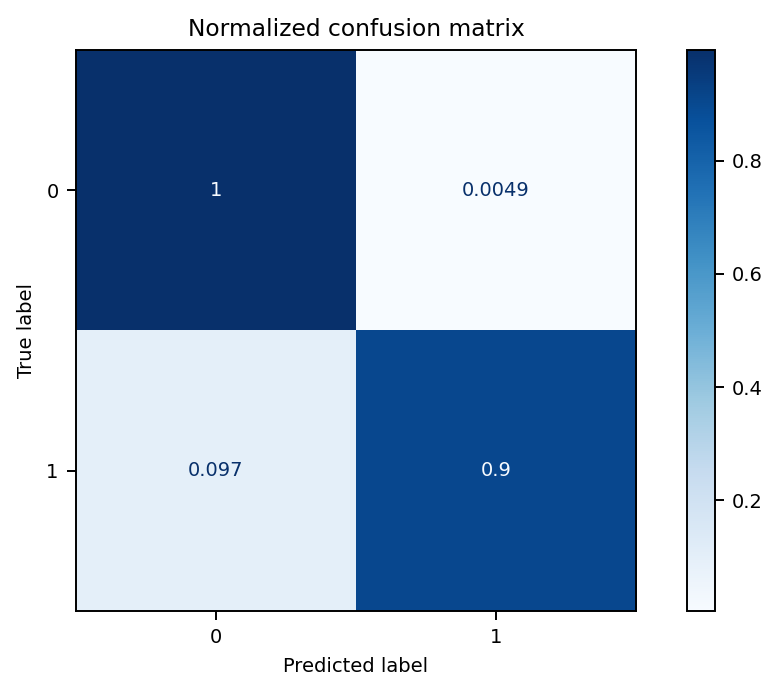

In [0]:
eval_confusion_matrix_path = os.path.join(eval_path, "val_confusion_matrix.png")
display(Image(filename=eval_confusion_matrix_path))

### ROC curve for validation dataset

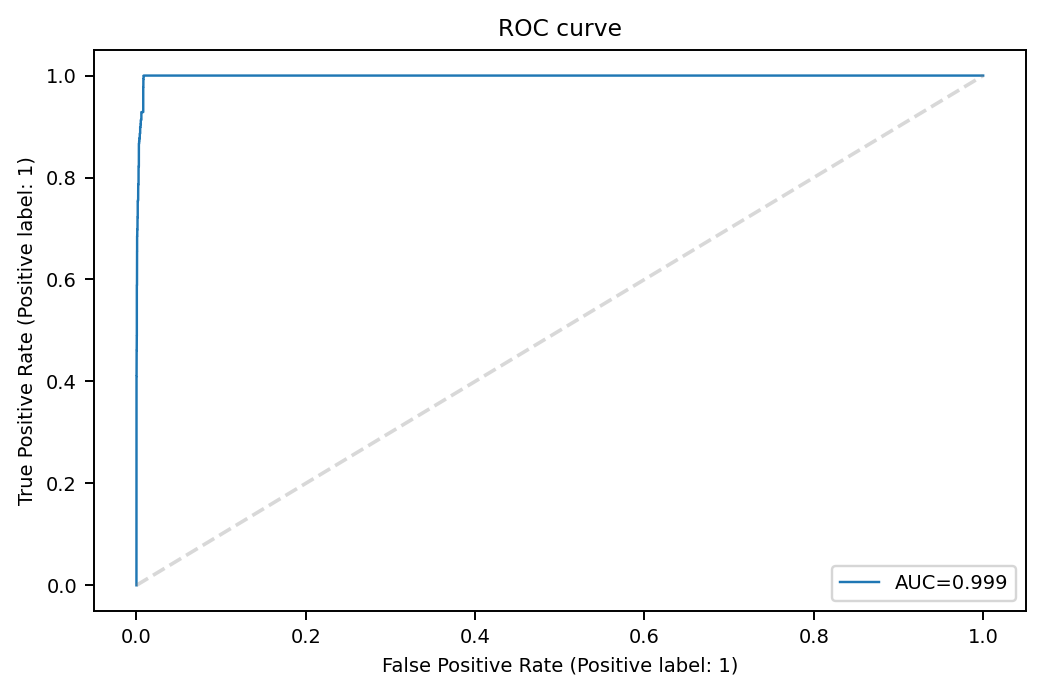

In [0]:
eval_roc_curve_path = os.path.join(eval_path, "val_roc_curve_plot.png")
display(Image(filename=eval_roc_curve_path))

### Precision-Recall curve for validation dataset

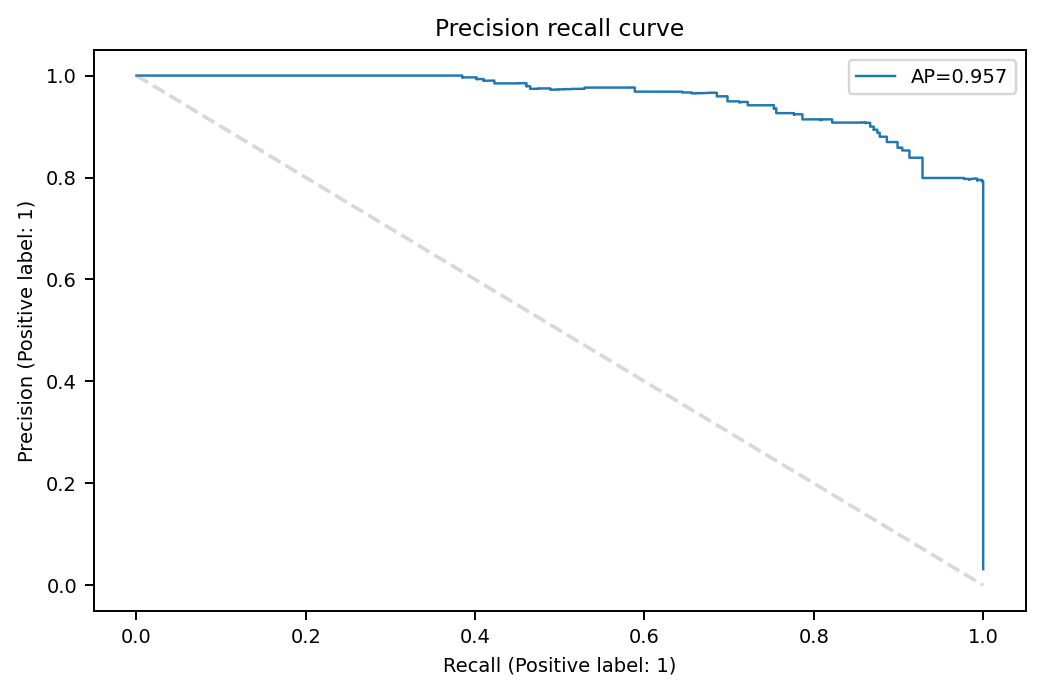

In [0]:
eval_pr_curve_path = os.path.join(eval_path, "val_precision_recall_curve_plot.png")
display(Image(filename=eval_pr_curve_path))

### MLFlow tracked all our model information and the model is ready to be deployed in our registry!
We can do that manually:

<img src="https://github.com/QuentinAmbard/databricks-demo/raw/main/retail-cdc-forecast/resources/images/mlflow_artifact.gif" alt="MLFlow artifacts"/>

or using MLFlow APIs directly:

In [0]:
model_name = "dbdemos_fsi_fraud"
from mlflow import MlflowClient

#Use Databricks Unity Catalog to save our model
mlflow.set_registry_uri('databricks-uc')
client = MlflowClient()

#Fix pandas to a specific version to support all dbr version
force_pandas_version(mlflow_run.info.run_id)

def save_mode_to_registry():
  #Add model within our catalog
  latest_model = mlflow.register_model(f'runs:/{mlflow_run.info.run_id}/model', f"{catalog}.{db}.{model_name}")
  print(f"Updating model to version {latest_model.version}")
  # Flag it as Production ready using UC Aliases
  client.set_registered_model_alias(name=f"{catalog}.{db}.{model_name}", alias="prod", version=latest_model.version)
  DBDemos.set_model_permission(f"{catalog}.{db}.{model_name}", "ALL_PRIVILEGES", "account users")

try:
  #Get the model if it is already registered to avoid re-deploying the endpoint
  latest_model = client.get_model_version_by_alias(f"{catalog}.{db}.{model_name}", "prod")
  print(f"Our model is already deployed on UC: {catalog}.{db}.{model_name}")
  #save_mode_to_registry() 
except:  
  save_mode_to_registry()

Our model is already deployed on UC: main.dbdemos_fsi_fraud_detection.dbdemos_fsi_fraud


We just moved our model as production ready! [Open the dbdemos_fsi_fraud model](#mlflow/models/dbdemos_fsi_fraud) to explore its artifact and analyze the parameters used, including traceability to the notebook used for its creation.

## Next: deploying our model for Real Time fraud detection serving 

Now that our model has been created with Databricks AutoML, we can start a Model Endpoint to serve low-latencies fraud detection.

We'll be able to rate the Fraud likelihood in ms to reduce fraud in real-time.

Open the [04.3-Model-serving-realtime-inference-fraud]($./04.3-Model-serving-realtime-inference-fraud) to deploy our model.